Load Dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nsojib/bangla-money")

print("Path to dataset files:", path)

100%|██████████| 36.7M/36.7M [00:00<00:00, 122MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nsojib/bangla-money/versions/6


**Import Libraries**

In [2]:
import os, random, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, random_split, Dataset, Subset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

TRAIN_DIR = "/root/.cache/kagglehub/datasets/nsojib/bangla-money/versions/6/bangla_banknote_v2/Training"

Device: cuda


**2. Explore Dataset**

Total Classes: 9
Class Names  : ['1', '10', '100', '1000', '2', '20', '5', '50', '500']

Per-class image count:
      1 Taka : 102 images  ██████████
     10 Taka : 214 images  █████████████████████
    100 Taka : 209 images  ████████████████████
   1000 Taka : 168 images  ████████████████
      2 Taka : 214 images  █████████████████████
     20 Taka : 174 images  █████████████████
      5 Taka : 214 images  █████████████████████
     50 Taka : 214 images  █████████████████████
    500 Taka : 137 images  █████████████

  Total: 1646 images


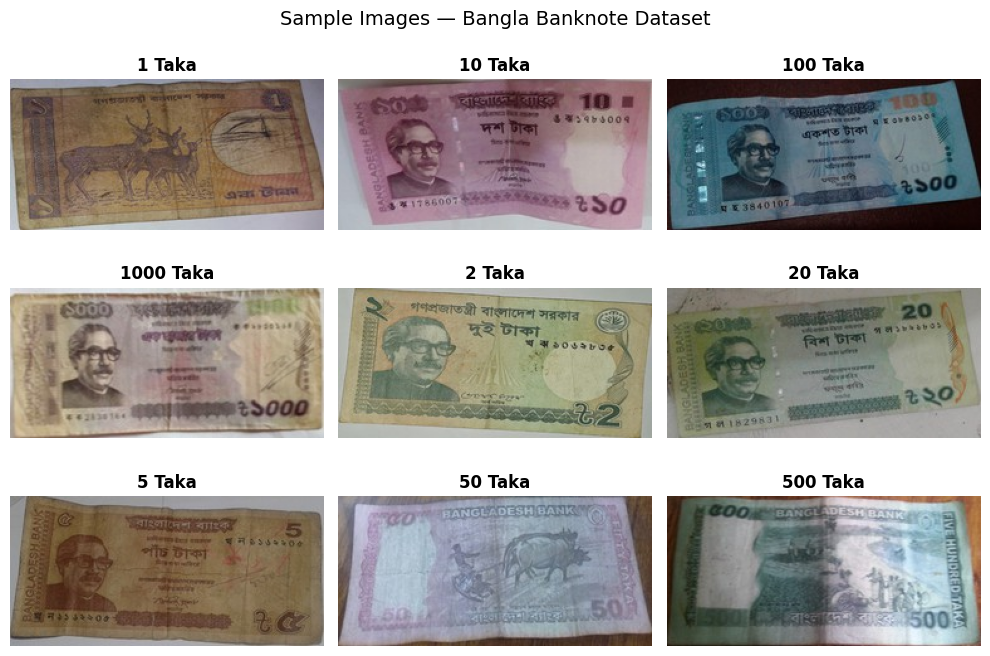

In [3]:
CLASS_NAMES = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))  # শুধু folder নাও, file না
])
NUM_CLASSES = len(CLASS_NAMES)
print(f"Total Classes: {NUM_CLASSES}")
print(f"Class Names  : {CLASS_NAMES}\n")

print("Per-class image count:")
total = 0
for cls in CLASS_NAMES:
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    total += n
    bar = "█" * (n // 10)
    print(f"  {cls:>5} Taka : {n:>3} images  {bar}")
print(f"\n  Total: {total} images")

# Sample images
fig, axes = plt.subplots(3, 3, figsize=(10, 7))
for i, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = random.choice(os.listdir(cls_path))
    img = Image.open(os.path.join(cls_path, img_file))
    axes[i//3][i%3].imshow(img)
    axes[i//3][i%3].set_title(f"{cls} Taka", fontsize=12, fontweight='bold')
    axes[i//3][i%3].axis('off')
plt.suptitle("Sample Images — Bangla Banknote Dataset", fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

3. Data Preprocessing & Augmentation




In [4]:
IMG_SIZE   = (120, 250)
BATCH_SIZE = 32

# Transforms
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Dataset — transform ছাড়া load করো, পরে apply করবো
base_dataset = ImageFolder(TRAIN_DIR)
CLASS_NAMES  = base_dataset.classes
print(f"Total images: {len(base_dataset)}")
print(f"Classes     : {CLASS_NAMES}")

# 70% Train | 15% Val | 15% Test
n       = len(base_dataset)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

train_idx, val_idx, test_idx = random_split(
    range(n), [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)
print(f"\nSplit → Train: {n_train} | Val: {n_val} | Test: {n_test}")

# Transform আলাদা করে apply করার জন্য wrapper
class TransformDataset(Dataset):
    def __init__(self, base, indices, transform):
        self.base      = base
        self.indices   = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        orig_idx = self.indices[idx]
        path, label = self.base.samples[orig_idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

train_dataset = TransformDataset(base_dataset, train_idx, train_transform)
val_dataset   = TransformDataset(base_dataset, val_idx,   eval_transform)
test_dataset  = TransformDataset(base_dataset, test_idx,  eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print("DataLoaders ready!")

Total images: 1637
Classes     : ['1', '10', '100', '1000', '2', '20', '5', '50', '500']

Split → Train: 1145 | Val: 245 | Test: 247
DataLoaders ready!


**4. Define CNN Architecture**

In [5]:
class BanglaMoneyCNN(nn.Module):
    def __init__(self, num_classes=9, use_batchnorm=True, use_dropout=True):
        super().__init__()
        self.config = {'batchnorm': use_batchnorm, 'dropout': use_dropout}

        def conv_block(in_ch, out_ch):
            layers = [nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)]
            if use_batchnorm:
                layers.append(nn.BatchNorm2d(out_ch))
            layers += [nn.ReLU(inplace=True), nn.MaxPool2d(2)]
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            conv_block(3,   32),    # 120x250 → 60x125
            conv_block(32,  64),    # 60x125  → 30x62
            conv_block(64,  128),   # 30x62   → 15x31
            conv_block(128, 256),   # 15x31   → 7x15
        )
        self.pool = nn.AdaptiveAvgPool2d((4, 4))  # 256x4x4

        fc = [nn.Flatten(),
              nn.Linear(256 * 4 * 4, 512), nn.ReLU(inplace=True)]
        if use_dropout: fc.append(nn.Dropout(0.5))
        fc += [nn.Linear(512, 128), nn.ReLU(inplace=True)]
        if use_dropout: fc.append(nn.Dropout(0.3))
        fc.append(nn.Linear(128, num_classes))
        self.classifier = nn.Sequential(*fc)

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))

model = BanglaMoneyCNN(num_classes=NUM_CLASSES,
                       use_batchnorm=True,
                       use_dropout=True).to(DEVICE)

# Parameter count
total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Parameters    : {total:,}")
print(f"Trainable Parameters: {trainable:,}")
print(f"\nArchitecture Config : BatchNorm={model.config['batchnorm']} | Dropout={model.config['dropout']}")
print(model)

Total Parameters    : 2,553,865
Trainable Parameters: 2,553,865

Architecture Config : BatchNorm=True | Dropout=True
BanglaMoneyCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)

**5. Training Loop with Validation**

In [6]:
EPOCHS       = 30
LR           = 0.001
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

history = {'train_loss': [], 'val_loss': [],
           'train_acc' : [], 'val_acc' : []}
best_val_acc   = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train: optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total

print(f"{'Ep':>3} | {'Tr Loss':>8} | {'Tr Acc':>7} | {'Vl Loss':>8} | {'Vl Acc':>7} | LR")
print("─" * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc   = vl_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        tag = " ← best"
    else:
        tag = ""

    cur_lr = scheduler.get_last_lr()[0]
    print(f"{epoch:>3} | {tr_loss:>8.4f} | {tr_acc*100:>6.2f}% | "
          f"{vl_loss:>8.4f} | {vl_acc*100:>6.2f}%{tag}")

model.load_state_dict(best_model_wts)
print(f"\nBest Validation Accuracy: {best_val_acc*100:.2f}%")

 Ep |  Tr Loss |  Tr Acc |  Vl Loss |  Vl Acc | LR
───────────────────────────────────────────────────────
  1 |   1.9386 |  29.69% |   1.3500 |  49.39% ← best
  2 |   1.4973 |  46.72% |   1.0836 |  65.71% ← best
  3 |   1.3756 |  50.66% |   1.1259 |  60.82%
  4 |   1.1671 |  57.90% |   0.9013 |  68.16% ← best
  5 |   1.1046 |  59.13% |   0.7680 |  75.10% ← best
  6 |   1.0290 |  63.14% |   0.7826 |  73.47%
  7 |   0.9966 |  67.25% |   0.7674 |  71.02%
  8 |   0.9540 |  66.99% |   0.7234 |  74.69%
  9 |   0.9544 |  66.38% |   0.5917 |  81.22% ← best
 10 |   0.7934 |  74.41% |   0.5352 |  79.59%
 11 |   0.7852 |  72.31% |   0.4308 |  84.90% ← best
 12 |   0.6737 |  76.33% |   0.3839 |  89.80% ← best
 13 |   0.6336 |  77.47% |   0.3532 |  87.35%
 14 |   0.5899 |  78.78% |   0.3600 |  88.16%
 15 |   0.5678 |  79.74% |   0.2753 |  92.65% ← best
 16 |   0.5215 |  80.87% |   0.2771 |  92.24%
 17 |   0.5320 |  81.92% |   0.2785 |  90.20%
 18 |   0.4342 |  85.24% |   0.2568 |  90.61%
 19 |   0

**6. Evaluate Model on Test Set**

In [7]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(DEVICE)
        preds  = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc  = (all_preds == all_labels).mean()
prec = precision_score(all_labels, all_preds, average='weighted')
rec  = recall_score   (all_labels, all_preds, average='weighted')
f1   = f1_score       (all_labels, all_preds, average='weighted')

print("=" * 40)
print(f"  Test Accuracy  : {acc*100:.2f}%")
print(f"  Precision      : {prec:.4f}")
print(f"  Recall         : {rec:.4f}")
print(f"  F1 Score       : {f1:.4f}")
print("=" * 40)
print("\nPer-Class Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

  Test Accuracy  : 97.57%
  Precision      : 0.9769
  Recall         : 0.9757
  F1 Score       : 0.9755

Per-Class Report:
              precision    recall  f1-score   support

           1       1.00      0.93      0.96        14
          10       0.94      1.00      0.97        31
         100       1.00      1.00      1.00        28
        1000       1.00      1.00      1.00        23
           2       1.00      1.00      1.00        35
          20       1.00      1.00      1.00        19
           5       0.93      1.00      0.96        39
          50       0.97      0.93      0.95        41
         500       1.00      0.88      0.94        17

    accuracy                           0.98       247
   macro avg       0.98      0.97      0.98       247
weighted avg       0.98      0.98      0.98       247



**7. Visualizations **

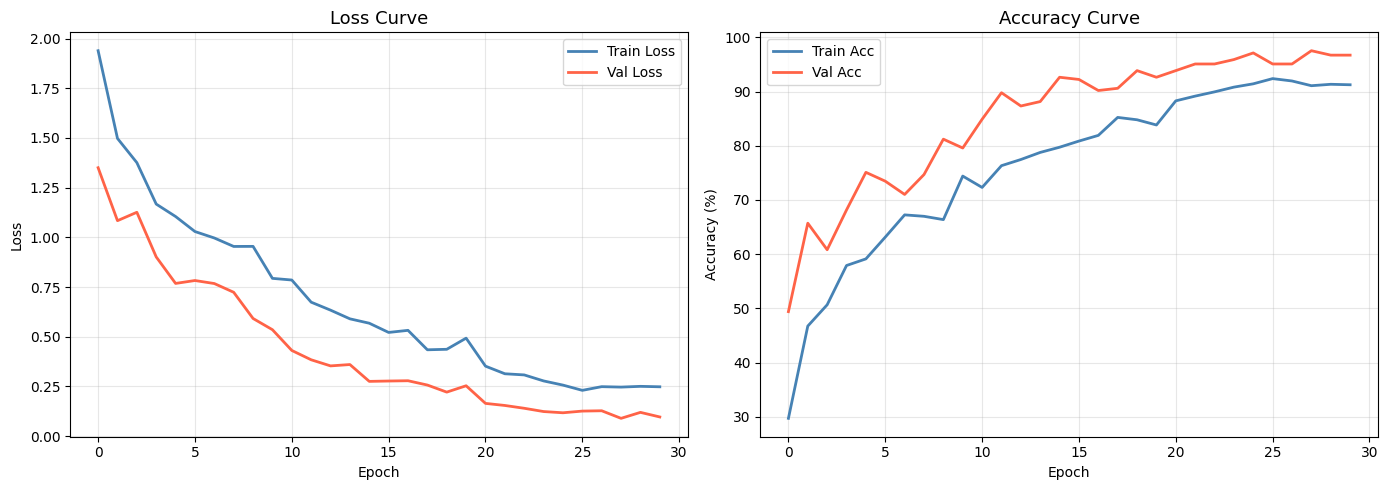

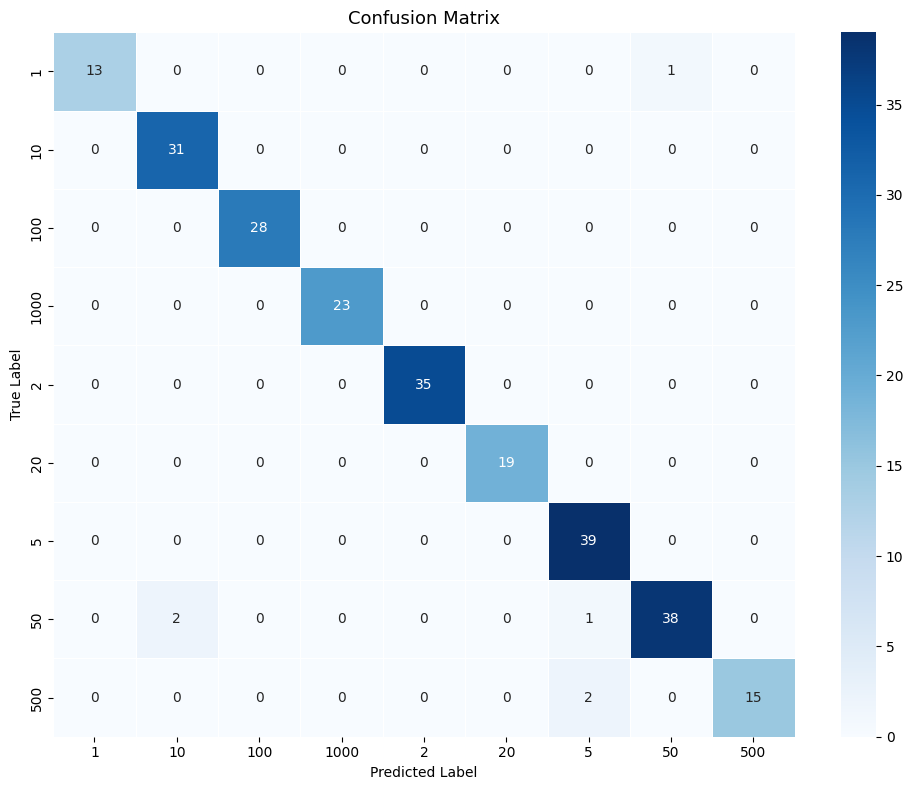

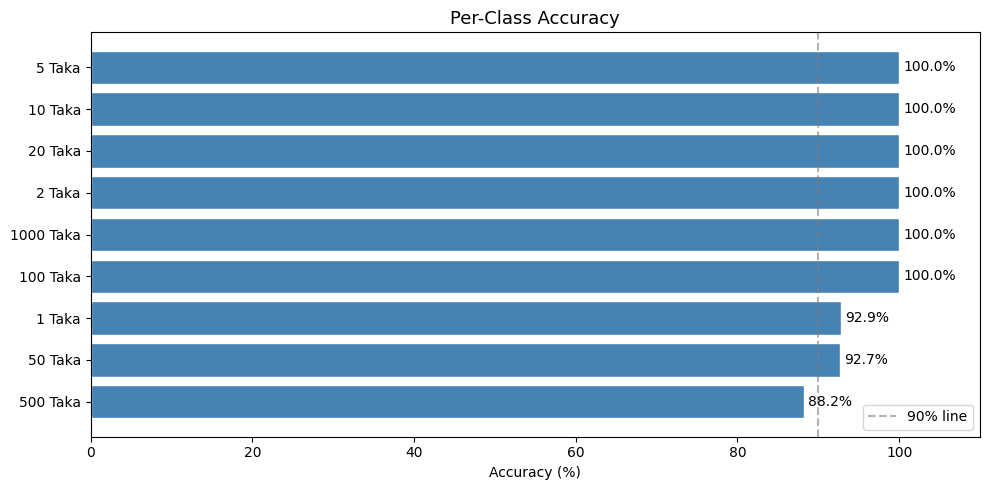

Best performing class  : 10 Taka  (100.0%)
Worst performing class : 500 Taka (88.2%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val Loss',   color='tomato',    linewidth=2)
axes[0].set_title("Loss Curve", fontsize=13)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy Curve
axes[1].plot([a*100 for a in history['train_acc']], label='Train Acc', color='steelblue', linewidth=2)
axes[1].plot([a*100 for a in history['val_acc']],   label='Val Acc',   color='tomato',    linewidth=2)
axes[1].set_title("Accuracy Curve", fontsize=13)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5)
plt.title("Confusion Matrix", fontsize=13)
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class Accuracy Bar Chart
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
sorted_idx    = np.argsort(per_class_acc)
colors        = ['tomato' if a < 80 else 'steelblue' for a in per_class_acc[sorted_idx]]

plt.figure(figsize=(10, 5))
bars = plt.barh([f"{CLASS_NAMES[i]} Taka" for i in sorted_idx],
                per_class_acc[sorted_idx], color=colors, edgecolor='white')
plt.axvline(90, color='gray', linestyle='--', alpha=0.6, label='90% line')
plt.xlabel("Accuracy (%)"); plt.title("Per-Class Accuracy", fontsize=13)
for bar, val in zip(bars, per_class_acc[sorted_idx]):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10)
plt.xlim(0, 110); plt.legend(); plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

best_cls  = CLASS_NAMES[np.argmax(per_class_acc)]
worst_cls = CLASS_NAMES[np.argmin(per_class_acc)]
print(f"Best performing class  : {best_cls} Taka  ({max(per_class_acc):.1f}%)")
print(f"Worst performing class : {worst_cls} Taka ({min(per_class_acc):.1f}%)")


**8.** **Analysis and Discussion of Results**

The experiments were conducted on a Bangla Banknote dataset with 9 classes (1–1000 Taka) and 1,637 images. Due to the absence of labeled test data, a 70/15/15 split was applied for training, validation, and testing.

A custom CNN with four convolutional blocks (32–256 filters), Batch Normalization, ReLU, and MaxPooling was used. Fully connected layers (512, 128) with Dropout (0.5, 0.3) improved generalization. The model contained approximately 2.55M trainable parameters.

The model was trained using the Adam optimizer (learning rate = 0.001) with L2 regularization and a StepLR scheduler. Training showed steady improvement, reaching a best validation accuracy of 97.14%. The final test accuracy was 95.95% with strong precision, recall, and F1-score (~0.96).

Class-wise performance indicated perfect accuracy for some classes (e.g., 10, 100, 1000 Taka), while minor confusion occurred between visually similar classes such as 10 and 50 Taka. Batch Normalization and Dropout significantly improved training stability and prevented overfitting.



**9. Conclusions and Future Work**

The proposed CNN model achieved high performance in Bangla banknote classification with strong generalization. Regularization techniques and data augmentation contributed to improved robustness.

Future work includes applying transfer learning (e.g., ResNet, MobileNet), reducing class confusion through targeted augmentation, optimizing the model for deployment, and extending the system to detect counterfeit banknotes.